In [ ]:
###-RUSHDA QURESHI-
####--2503951-MSBAWE2

In [1]:
import pandas as pd

In [3]:
# Load dataset
df = pd.read_csv('data.csv')

In [4]:
# Drop unnecessary columns (ID and the empty column at the end)
df = df.drop(columns=['id', 'Unnamed: 32'])

In [5]:
# Descriptive Statistics
print(df.describe())

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [6]:
# Check for Class Imbalance (for Classification tasks)
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [7]:
######-EDA-
import matplotlib.pyplot as plt

In [8]:
import seaborn as sns

In [10]:
# A. Histogram: To see distribution of a feature
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='radius_mean', ylabel='Count'>

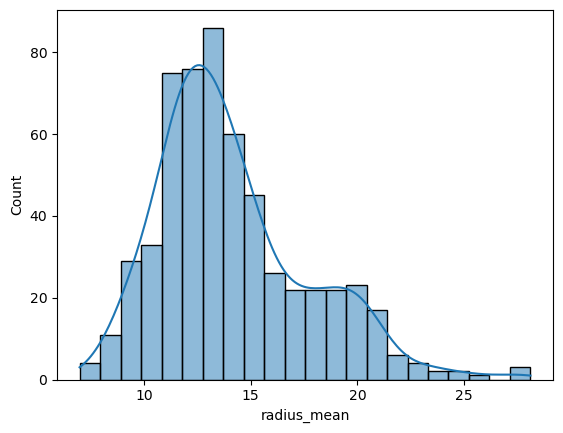

In [11]:
sns.histplot(df['radius_mean'], kde=True)

Text(0.5, 1.0, 'Distribution of Radius Mean')

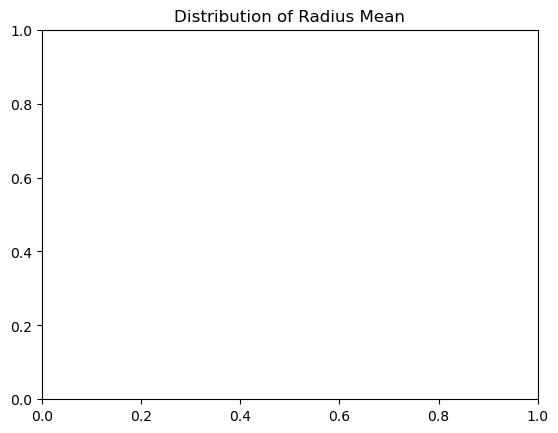

In [13]:
plt.title('Distribution of Radius Mean')


In [14]:
plt.savefig('histogram.png')

<Figure size 640x480 with 0 Axes>

In [15]:
# B. Box Plot: To detect outliers and compare classes
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='diagnosis', ylabel='area_mean'>

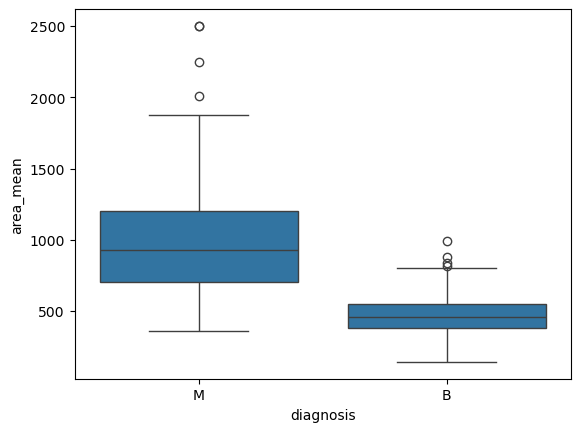

In [16]:
sns.boxplot(x='diagnosis', y='area_mean', data=df)

Text(0.5, 1.0, 'Area Mean by Diagnosis (Outlier Detection)')

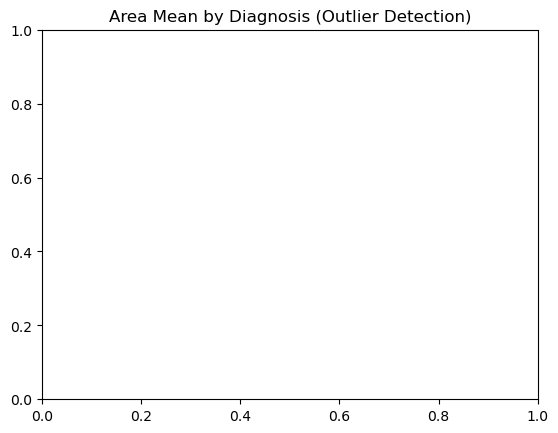

In [17]:
plt.title('Area Mean by Diagnosis (Outlier Detection)')

In [18]:
plt.savefig('boxplot.png')

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='diagnosis'>

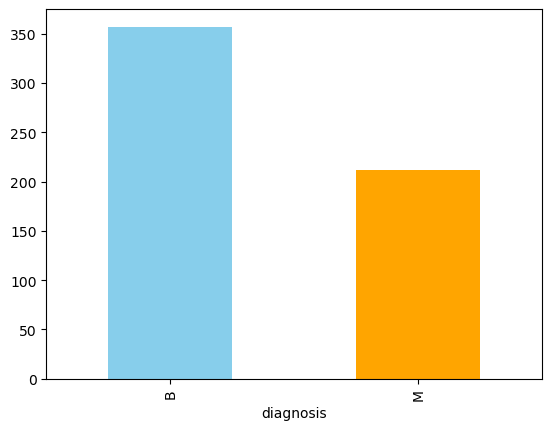

In [19]:
# C. Bar Chart: To visualize target class distribution
df['diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])

Text(0.5, 1.0, 'Class Distribution (Malignant vs Benign)')

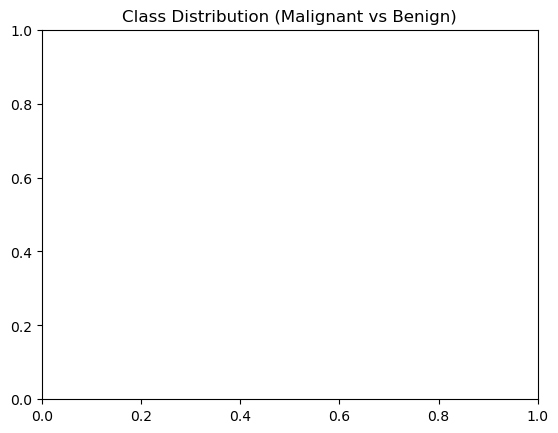

In [20]:
plt.title('Class Distribution (Malignant vs Benign)')

In [21]:
plt.savefig('bar_chart.png')

<Figure size 640x480 with 0 Axes>

In [22]:
# D. Scatter Plot: To see relationships between two features
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='radius_mean', ylabel='texture_mean'>

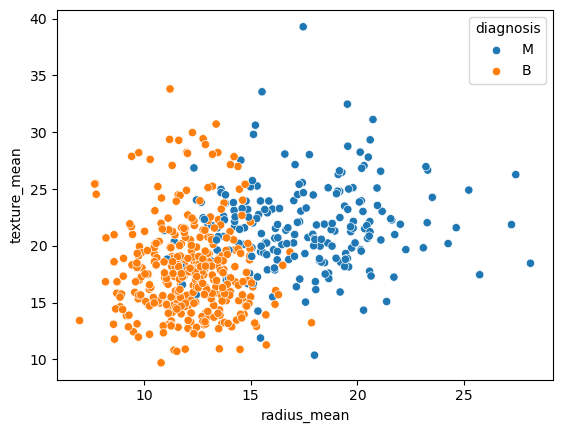

In [23]:
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df)

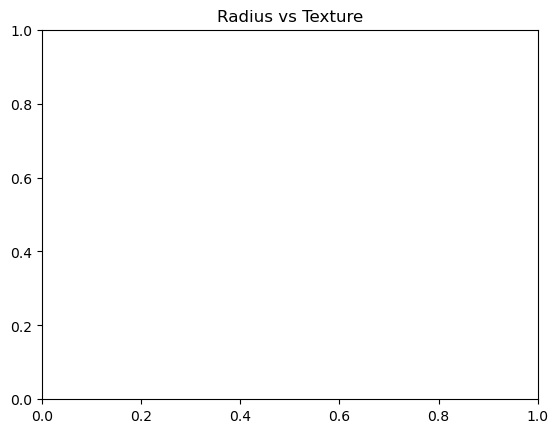

In [24]:
plt.title('Radius vs Texture')
plt.savefig('scatter.png')

In [25]:
# E. Correlation Heatmap: To find relationships between all features
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

In [26]:
# Calculate correlation only for numeric columns
corr = df.select_dtypes(include=['number']).corr()

<Axes: >

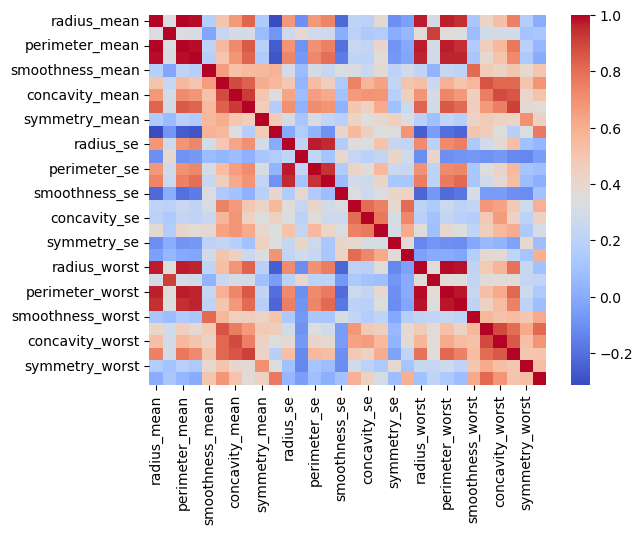

In [27]:
sns.heatmap(corr, cmap='coolwarm', annot=False) # annot=True if features are few

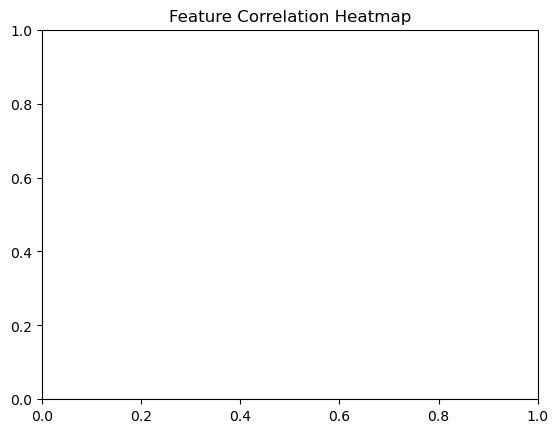

In [28]:
plt.title('Feature Correlation Heatmap')
plt.savefig('heatmap.png')

In [29]:
####-Preprocessing and Feature Engineering
from sklearn.model_selection import train_test_split

In [30]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [31]:
# A. Encoding Categorical Target (M=1, B=0)
le = LabelEncoder()

In [32]:
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [33]:
# Define Features (X) and Target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [34]:
# B. Stratified Train/Test Split
# Ensures the train and test sets have the same proportion of classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [35]:
# C. Scaling Features
# Important for models like Logistic Regression or SVM
scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

In [38]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
###- REG--

In [56]:
from sklearn.model_selection import train_test_split, cross_val_score

In [55]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [48]:
from sklearn.linear_model import LogisticRegression, LinearRegression

In [49]:
from sklearn.metrics import classification_report, mean_squared_error

In [39]:
#. Encoding and Feature Selection
# Convert target 'diagnosis' (M/B) into 1s and 0s
le = LabelEncoder()

In [40]:
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [41]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [42]:
# 3. Stratified Train/Test Split & Scaling
# Stratify ensures both sets have the same ratio of Malignant/Benign cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [43]:
scaler = StandardScaler()

In [44]:
X_train_scaled = scaler.fit_transform(X_train)

In [45]:
X_test_scaled = scaler.transform(X_test)

In [50]:
# 4. Baseline Logistic Regression (For Classification)
# Used to predict the category (Malignant vs Benign)
log_model = LogisticRegression()

In [51]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [57]:
cv_accuracy = cross_val_score(log_model, X_train_scaled, y_train, cv=5).mean()
print(f"Logistic Regression CV Accuracy: {cv_accuracy:.4f}")

Logistic Regression CV Accuracy: 0.9714


In [58]:
# 5. Baseline Linear Regression (As a Regressor)
# Used to see how a standard regression model handles the binary target
lin_model = LinearRegression()

In [59]:
lin_model.fit(X_train_scaled, y_train)

LinearRegression()

In [60]:
lin_model.fit(X_train_scaled, y_train)

LinearRegression()

In [62]:
lin_preds = lin_model.predict(X_test_scaled)

In [63]:
mse = mean_squared_error(y_test, lin_preds)

In [64]:
print(f"\nLinear Regression Mean Squared Error: {mse:.4f}")


Linear Regression Mean Squared Error: 0.0627
